In [1]:
##### Creates maps of agricultural production (rasters)

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors

In [24]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import data
livestock = rio.open_rasterio(f"{cd}/Data/Clean/Production/livestock_production_USD_2020.tif")
crop = rio.open_rasterio(f"{cd}/Data/Clean/Production/crop_production_USD_2020.tif")
total = rio.open_rasterio(f"{cd}/Data/Clean/Production/total_production_USD_2020.tif")

country_boundaries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures"

In [25]:
### Data prep

# align crs

crs = "ESRI:54042"

livestock = livestock.rio.reproject(crs)
crop = crop.rio.reproject(crs)
total = total.rio.reproject(crs)

country_boundaries = country_boundaries.to_crs(crs)

# convert to USD million 
livestock_million = livestock / 1e6
crops_million = crop / 1e6
total_million = total / 1e6


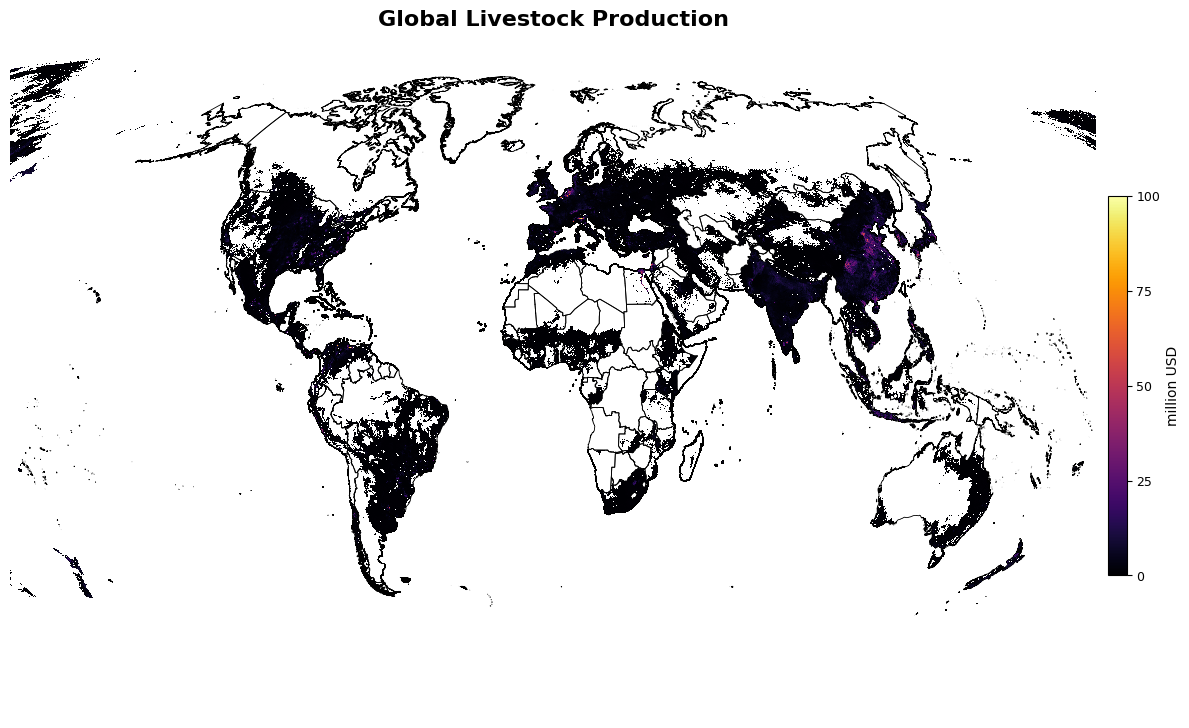

In [29]:
##### Produce global map of livestock production (USD)

# Prepare raster
livestock_plot = livestock_million.squeeze()
livestock_masked = livestock_plot.where(livestock_plot > 0.1)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders underneath
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=1
)

# Raster on top
im = livestock_masked.plot(
    ax=ax,
    cmap="inferno",
    vmin=0.1,
    vmax=100,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

ax.set_axis_off()
ax.set_title("Global Livestock Production", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("million USD", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 25, 50, 75, 100])

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/livestock_production_raster.png", dpi=300, bbox_inches='tight')

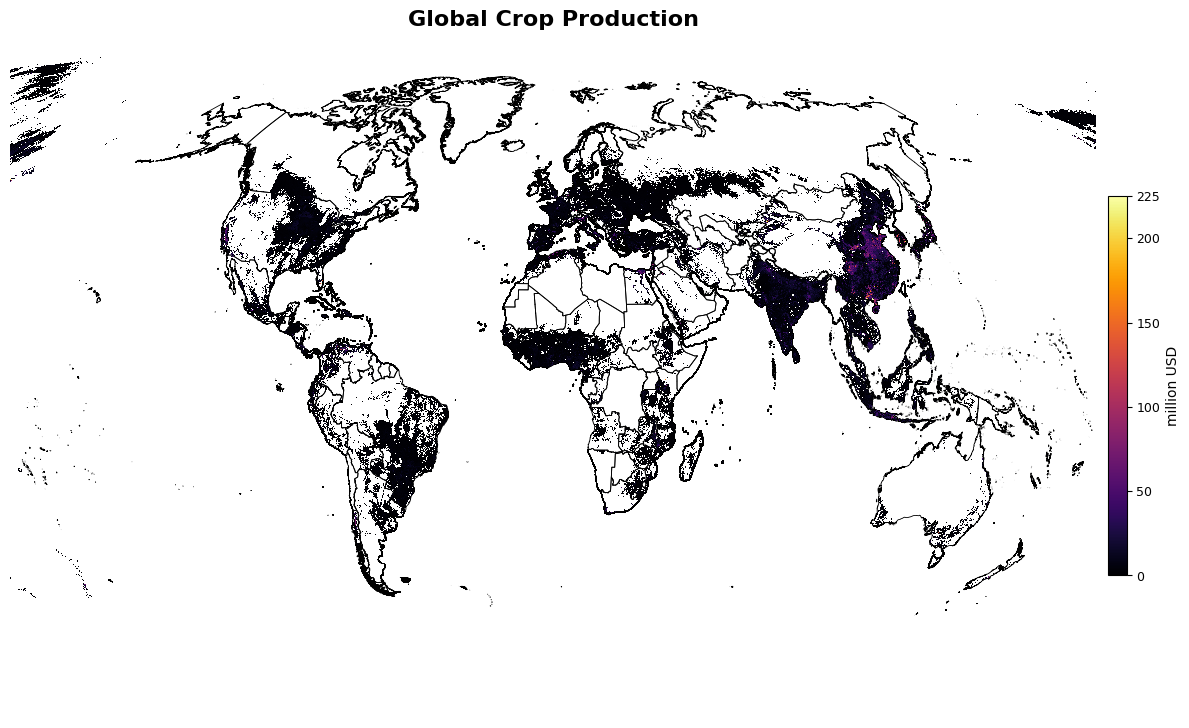

In [30]:
##### Produce global map of crop production (USD)

# Prepare raster
crop_plot = crops_million.squeeze()
crop_masked = crop_plot.where(crop_plot > 0.1)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders underneath
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=1
)

# Raster on top
im = crop_masked.plot(
    ax=ax,
    cmap="inferno",
    vmin=0.1,
    vmax=225,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

ax.set_axis_off()
ax.set_title("Global Crop Production", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("million USD", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 50, 100, 150, 200, 225])

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/crop_production_raster.png", dpi=300, bbox_inches='tight')

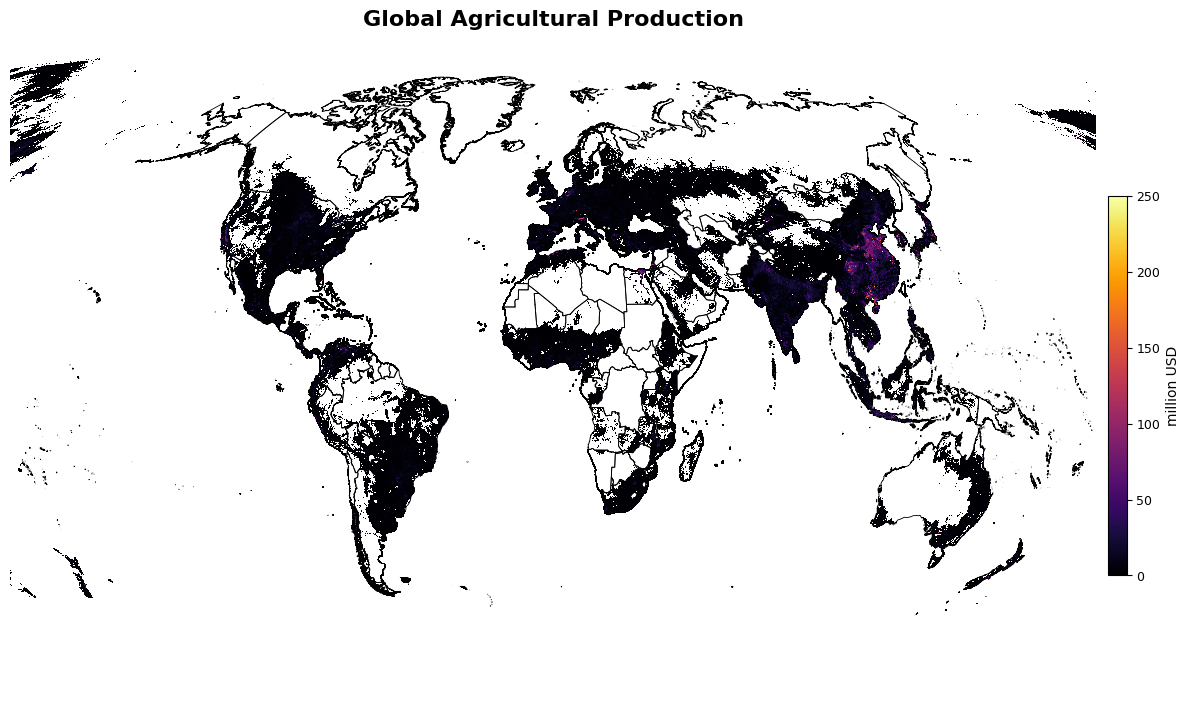

In [31]:
##### Produce global map of total production (USD)

# Prepare raster
total_plot = total_million.squeeze()
total_masked = total_plot.where(total_plot > 0.1)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders underneath
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=1
)

# Raster on top
im = total_masked.plot(
    ax=ax,
    cmap="inferno",
    vmin=0.1,
    vmax=250,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

ax.set_axis_off()
ax.set_title("Global Agricultural Production", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("million USD", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 50, 100, 150, 200, 250])

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/total_production_raster.png", dpi=300, bbox_inches='tight')